# Start SBI Dataset

This notebook prepares the new 512-row Battaglia y100/y102 dataset for `sbi`. It reads the combined cluster output NPZ, keeps the Sobol parameter rows, converts raw spectra to `log10(D_l)`, estimates the paired-lightcone scatter, and exposes `torch.float32` tensors ready for `inference.append_simulations(theta, x)`.


In [1]:
from matplotlib.ticker import LinearLocator, MaxNLocator
import matplotlib.pyplot as plt
from pathlib import Path
import sys

import numpy as np

try:
    import torch
except ModuleNotFoundError:
    torch = None

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from sbi.analysis import pairplot
    from sbi.analysis.plotting_classes import KdeOffDiagOptions
    from sbi.analysis.plotting_classes import (
        HistDiagOptions,
        HistOffDiagOptions,
        FigOptions,
        ScatterOffDiagOptions,
        ContourOffDiagOptions,
    )
    from sbi.inference import NPE
except ModuleNotFoundError:
    pairplot = None
    KdeOffDiagOptions = None
    HistDiagOptions = None
    HistOffDiagOptions = None
    FigOptions = None
    NPE = None


In [2]:
from sbi.analysis.plotting_classes import (
    FigOptions,
    HistDiagOptions,
    KdeDiagOptions,
    ScatterDiagOptions,
    ScatterOffDiagOptions,
    ContourOffDiagOptions,
    KdeOffDiagOptions,
    HistOffDiagOptions,
)


def _as_tensor(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu()
    return torch.as_tensor(x)


def _is_none_kind(kind):
    return kind is None or str(kind).lower() in ["none", "off", "empty", "blank"]


def _diag_options(kind, color, cmap, bins):
    kind = str(kind).lower()

    if kind == "hist":
        return HistDiagOptions(
            mpl_kwargs={
                "color": color,
                "bins": bins,
                "alpha": 0.45,
                "histtype": "stepfilled",
                "density": True,
            }
        )

    elif kind == "kde":
        return KdeDiagOptions(
            mpl_kwargs={
                "color": color,
                "alpha": 0.9,
            }
        )

    elif kind == "scatter":
        return ScatterDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 8,
                "alpha": 0.3,
            }
        )

    else:
        raise ValueError(
            f"Unsupported diagonal plot kind: {kind}. "
            "Use 'hist', 'kde', or 'scatter'."
        )


def _offdiag_options(
    kind,
    color,
    cmap,
    hidden=False,
    scatter_cmap=None,
    scatter_gradient=False,
    n_points=None,
):
    kind = str(kind).lower()

    if hidden:
        return ScatterOffDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 0,
                "alpha": 0.0,
            }
        )

    if kind == "scatter":
        if scatter_gradient:
            if n_points is None:
                raise ValueError("n_points is required for scatter_gradient=True.")

            scatter_kwargs = {
                "color": None,
                "c": np.linspace(0, 1, n_points),
                "cmap": scatter_cmap if scatter_cmap is not None else cmap,
                "s": 6,
                "alpha": 0.35,
                "rasterized": True,
            }
        else:
            scatter_kwargs = {
                "color": color,
                "s": 6,
                "alpha": 0.20,
                "rasterized": True,
            }

        return ScatterOffDiagOptions(mpl_kwargs=scatter_kwargs)

    elif kind == "contour":
        return ContourOffDiagOptions(
            mpl_kwargs={
                "colors": color,
                "alpha": 0.9,
            },
            levels=[0.68, 0.95],
        )

    elif kind == "kde":
        return KdeOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
                "alpha": 0.8,
            }
        )

    elif kind == "hist":
        return HistOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
            }
        )

    else:
        raise ValueError(
            f"Unsupported off-diagonal plot kind: {kind}. "
            "Use 'scatter', 'contour', 'kde', 'hist', or 'none'."
        )

def sbi_pairplot(
    samples,
    param_names,
    true_values=None,
    sample_labels=None,
    colors=None,
    cmaps=None,
    limits=None,
    subset=None,
    diag="hist",
    upper="contour",
    lower="scatter",
    bins=40,
    figsize=None,
    title=None,
    savepath=None,
    scatter_cmap=None,
    scatter_gradient=False,
    diag_param_labels=True,
):
    """
    Flexible pairplot wrapper for sbi posterior samples.

    Parameters
    ----------
    samples:
        Tensor/array of shape (N, ndim), or list of such arrays.
    param_names:
        List of parameter names.
    true_values:
        Optional fiducial/true parameter vector with shape (ndim,).
    sample_labels:
        Optional labels for multiple posterior sample sets.
    colors:
        Optional list of colors, one per sample set.
    cmaps:
        Optional list of colormaps, one per sample set.
    limits:
        Optional axis limits passed to sbi.analysis.pairplot.
    subset:
        Optional subset of parameters to plot, e.g. [0, 2, 4].
    diag:
        'hist', 'kde', or 'scatter'.
    upper:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    lower:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    """

    from matplotlib.ticker import LinearLocator as _LinearLocator

    # Allow one dataset or multiple datasets
    if not isinstance(samples, (list, tuple)):
        samples = [samples]

    samples = [_as_tensor(s) for s in samples]
    n_sets = len(samples)

    ndim = samples[0].shape[1]

    for s in samples:
        if s.ndim != 2:
            raise ValueError("Each sample set must have shape (N, ndim).")
        if s.shape[1] != ndim:
            raise ValueError("All sample sets must have the same number of parameters.")

    if len(param_names) != ndim:
        raise ValueError(
            f"param_names has length {len(param_names)}, but samples have ndim={ndim}."
        )

    if colors is None:
        colors = [f"C{i}" for i in range(n_sets)]

    if cmaps is None:
        default_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Greys"]
        cmaps = [default_cmaps[i % len(default_cmaps)] for i in range(n_sets)]

    if sample_labels is None:
        sample_labels = [f"samples {i}" for i in range(n_sets)]

    if len(colors) != n_sets:
        raise ValueError("colors must have one entry per sample set.")

    if len(cmaps) != n_sets:
        raise ValueError("cmaps must have one entry per sample set.")

    if len(sample_labels) != n_sets:
        raise ValueError("sample_labels must have one entry per sample set.")

    points = None
    point_labels = []
    if true_values is not None:
        points = _as_tensor(true_values)
        if points.ndim == 1:
            points = points[None, :]
        point_labels = [r"$\theta_\mathrm{true}$"]

    hide_upper = _is_none_kind(upper)
    hide_lower = _is_none_kind(lower)

    # sbi needs a valid plot type, so use invisible scatter internally.
    upper_for_pairplot = "scatter" if hide_upper else str(upper).lower()
    lower_for_pairplot = "scatter" if hide_lower else str(lower).lower()

    diag_kwargs = [
        _diag_options(diag, colors[i], cmaps[i], bins)
        for i in range(n_sets)
    ]

    upper_kwargs = [
        _offdiag_options(
            upper_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_upper,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and upper_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    lower_kwargs = [
        _offdiag_options(
            lower_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_lower,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and lower_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    if figsize is None:
        ndim_plot = len(subset) if subset is not None else ndim
        figsize = (2.4 * ndim_plot, 2.4 * ndim_plot)

    fig, axes = pairplot(
        samples,
        points=points,
        labels=param_names,
        limits=limits,
        subset=subset,
        diag=[str(diag).lower()] * n_sets,
        upper=[upper_for_pairplot] * n_sets,
        lower=[lower_for_pairplot] * n_sets,
        diag_kwargs=diag_kwargs,
        upper_kwargs=upper_kwargs,
        lower_kwargs=lower_kwargs,
        figsize=figsize,
        fig_kwargs=FigOptions(
            legend=True,
            samples_labels=sample_labels,
            samples_colors=colors,
            points_labels=point_labels,
            points_colors=["k"],
            points_offdiag={"marker": "+", "markersize": 14},
            points_diag={"marker": "+", "markersize": 14},
            title=title,
        ),
    )

    # Remove upper/lower triangle if requested
    axes_arr = np.asarray(axes)

    if axes_arr.ndim == 2:
        ndim_plot = axes_arr.shape[0]

        if hide_lower:
            for i in range(ndim_plot):
                for j in range(i):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

        if hide_upper:
            for i in range(ndim_plot):
                for j in range(i + 1, ndim_plot):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

    # Fix labels when one triangle is hidden.
    # sbi normally labels mostly outer axes, which may have been hidden.
    if diag_param_labels and axes_arr.ndim == 2:
        if subset is None:
            plotted_param_names = list(param_names)
        else:
            plotted_param_names = [param_names[i] for i in subset]

        for i, name in enumerate(plotted_param_names):
            ax = axes_arr[i, i]
            ax.set_xlabel(name)
            ax.set_title(name)

    if axes_arr.ndim == 2:
        for ax in axes_arr.ravel():
            if not ax.axison:
                continue
            ax.xaxis.set_major_locator(_LinearLocator(3))
            ax.yaxis.set_major_locator(_LinearLocator(3))
            ax.tick_params(
                axis="both",
                which="major",
                labelsize=8,
                bottom=True,
                left=True,
                labelbottom=True,
                labelleft=True,
            )
            ax.tick_params(axis="x", which="major", labelrotation=45)
            for label in ax.get_xticklabels():
                label.set_rotation(45)
                label.set_ha("right")

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, axes

In [3]:
# Make the notebook work whether Jupyter is started from the repo root, SBI_analysis, or tSZ_visuals.
CWD = Path.cwd().resolve()
if CWD.name == "SBI_analysis":
    PROJECT_ROOT = CWD.parent
elif (CWD / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD
elif (CWD.parent / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

SBI_DIR = PROJECT_ROOT / "SBI_analysis"
if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from sbi_utils import cl_to_log10_dl, estimate_lightcone_sigma, prior_bounds, selected_ell_mask

DATA_PATH = (
    PROJECT_ROOT
    / "HPC_output"
    / "HalfDome"
    / "ydata_4096"
    / "sbi_battaglia_y100_4096.npz"
)
METADATA_PATH = DATA_PATH.with_name("sbi_battaglia_y100_4096_metadata.csv")
MANIFEST_PATH = DATA_PATH.with_name("sbi_battaglia_y100_4096_manifest.json")

OBS_Y100_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome_fiducial_nside4096_cluster.npy"
OBS_Y102_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome102_fiducial_nside4096_cluster.npy"

ELL_MIN = 2
ELL_MAX = 4096
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

# New 1024-run Sobol priors.
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393,1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}

DATA_PATH


WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome/HPC_output/HalfDome/ydata_4096/sbi_battaglia_y100_4096.npz')

These are the true parameters that will later be used in the SBI

In [4]:
true_params = [18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758,  0.731, 0.415]

Functions that will later be applied for the compton-y profiles

In [5]:
def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    """
    Gaussian beam window function B_ell.
    """
    fwhm_rad = np.deg2rad(fwhm_arcmin / 60.0)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    B_ell = np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)

    return B_ell


def apply_gaussian_beam_to_cl(cl, fwhm_arcmin=1.6):
    """
    Apply Gaussian beam smoothing to an auto-power spectrum.
    """
    ells = np.arange(len(cl))
    B_ell = gaussian_beam_window(ells, fwhm_arcmin=fwhm_arcmin)

    cl_beamed = B_ell**2 * cl

    return cl_beamed, B_ell

## Read The 512 Combined Dataset

The generated NPZ stores the Sobol parameters as `theta` and the raw y100/y102 spectra as `C_l`. For SBI, this prepares `x = log10(D_l)` to match the previous notebook convention.


In [6]:
def load_generated_sbi_dataset(path, ell_min=2, ell_max=4096):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Missing SBI dataset: {path}")

    base_required = ["theta", "theta_columns", "ell"]
    with np.load(path, allow_pickle=True) as data:
        missing = [key for key in base_required if key not in data.files]
        if missing:
            raise KeyError(f"{path} is missing required arrays: {missing}")

        ell_all = np.asarray(data["ell"], dtype=float).reshape(-1)
        mask = selected_ell_mask(ell_all, ell_min, ell_max)
        theta_columns = [str(value) for value in np.asarray(data["theta_columns"]).tolist()]
        cl_keys = sorted(key for key in data.files if key.startswith("cl_y"))
        spectra = {
            key: np.asarray(data[key], dtype=float)[:, mask]
            for key in cl_keys
        }

        if spectra:
            shapes = {values.shape for values in spectra.values()}
            if len(shapes) != 1:
                raise ValueError(f"Spectrum arrays have inconsistent shapes: {shapes}")
            if len(spectra) == 1:
                cl_mean = next(iter(spectra.values()))
            else:
                cl_mean = np.mean(np.stack(list(spectra.values()), axis=0), axis=0)
        elif "cl_stack" in data.files:
            cl_stack = np.asarray(data["cl_stack"], dtype=float)
            if cl_stack.ndim != 3:
                raise ValueError(f"Expected cl_stack with shape (n, n_lightcones, ell), got {cl_stack.shape}")
            cl_stack = cl_stack[:, :, mask]
            if cl_stack.shape[1] == 0:
                raise ValueError(f"{path} contains an empty cl_stack")
            cl_mean = np.mean(cl_stack, axis=1)
        elif "cl_mean" in data.files:
            cl_mean = np.asarray(data["cl_mean"], dtype=float)[:, mask]
        else:
            raise KeyError(f"{path} has no C_l arrays matching cl_y*, cl_stack, or cl_mean")

        dataset = {
            "theta": np.asarray(data["theta"], dtype=float),
            "theta_columns": theta_columns,
            "ell": ell_all[mask],
            "cl_mean": cl_mean,
            "cl_keys": cl_keys,
            "source_path": str(path),
        }
        dataset.update(spectra)


    if dataset["theta"].shape[0] != dataset["cl_mean"].shape[0]:
        raise ValueError("theta rows and spectrum rows do not match")
    if dataset["theta"].shape[0] == 0:
        raise ValueError("Dataset contains no parameter rows")

    duplicate_count = dataset["theta"].shape[0] - np.unique(dataset["theta"], axis=0).shape[0]
    if duplicate_count:
        raise ValueError(f"Found {duplicate_count} duplicate parameter rows in {path}")

    return dataset


dataset = load_generated_sbi_dataset(DATA_PATH, ell_min=ELL_MIN, ell_max=ELL_MAX)
param_names = list(dataset["theta_columns"])
prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, param_names)

transformed = {"combined": cl_to_log10_dl(dataset["cl_mean"], dataset["ell"])}
for key in dataset["cl_keys"]:
    transformed[key[3:]] = cl_to_log10_dl(dataset[key], dataset["ell"])

# Keep arrays contiguous and float32 before handing them to torch.
theta_np = np.ascontiguousarray(dataset["theta"], dtype=np.float32)
x_np = np.ascontiguousarray(transformed["combined"], dtype=np.float32)
lightcone_names = [key[3:] for key in dataset["cl_keys"]]
if lightcone_names:
    first_lightcone = transformed[lightcone_names[0]]
    second_lightcone = transformed[lightcone_names[1]] if len(lightcone_names) > 1 else first_lightcone
    x_y100_np = np.ascontiguousarray(transformed.get("y100", first_lightcone), dtype=np.float32)
    x_y102_np = np.ascontiguousarray(transformed.get("y102", second_lightcone), dtype=np.float32)
else:
    x_y100_np = x_np
    x_y102_np = x_np
ell_np = np.ascontiguousarray(dataset["ell"], dtype=np.float32)

if len(lightcone_names) == 1:
    combined_label = lightcone_names[0]
elif lightcone_names:
    combined_label = "mean of " + ", ".join(lightcone_names)
else:
    combined_label = "cl_mean"

sigma_log10_dl_np = estimate_lightcone_sigma(
    x_y100_np,
    x_y102_np,
    target="single_lightcone",
    sigma_floor=1.0e-4,
    scale=1.0,
).astype(np.float32)

print(f"theta_np: {theta_np.shape}  parameters: {param_names}")
print(f"x_np:     {x_np.shape}  data vector: log10(D_l) from {combined_label}")
print(f"ell_np:   {ell_np.shape}  ell range: {ell_np[0]:.0f}-{ell_np[-1]:.0f}")
print(f"sigma:    {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")


theta_np: (4096, 9)  parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
x_np:     (4096, 4095)  data vector: log10(D_l) from y100
ell_np:   (4095,)  ell range: 2-4096
sigma:    (4095,)  median=0.0001


In [7]:
10**sigma_log10_dl_np

array([1.0002303, 1.0002303, 1.0002303, ..., 1.0002303, 1.0002303,
       1.0002303], dtype=float32)

## Optional Gaussian Beam

This keeps both the no-beam and 1.6 arcmin Gaussian-beam versions available. The beam is applied in `log10(D_l)` space by adding `log10(B_l^2)`.


In [8]:
def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=1.6):
    ell = np.asarray(ell, dtype=float)
    log10_dl = np.asarray(log10_dl, dtype=float)
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    beam_log_factor = np.log10(np.maximum(beam**2, 1.0e-40))
    return log10_dl + beam_log_factor


Gaussian_beam_bool = True
if Gaussian_beam_bool:
    x_np_gp = np.ascontiguousarray(
        apply_gaussian_beam_to_log10_dl(x_np, ell_np, fwhm_arcmin=1.6),
        dtype=np.float32,
    )
else:
    x_np_gp = x_np


## Sobol Parameters

`theta_np` is the Sobol sequence parameter matrix from the NPZ. Rows align one-to-one with `x_np`, `x_y100_np`, and `x_y102_np`.

In [9]:
if pd is not None:
    sobol_parameters = pd.DataFrame(theta_np, columns=param_names)
    parameter_summary = pd.DataFrame(
        {
            "parameter": param_names,
            "prior_low": prior_low_np,
            "prior_high": prior_high_np,
            "sobol_min": theta_np.min(axis=0),
            "sobol_max": theta_np.max(axis=0),
        }
    )
    display(parameter_summary)
    display(sobol_parameters.head())
else:
    sobol_parameters = theta_np
    parameter_summary = list(
        zip(param_names, prior_low_np, prior_high_np, theta_np.min(axis=0), theta_np.max(axis=0))
    )
    print("parameter, prior_low, prior_high, sobol_min, sobol_max")
    for row in parameter_summary:
        print(row)

,parameter,prior_low,prior_high,sobol_min,sobol_max
0,P0,1.832524,34.341221,1.816402,34.387661
1,xc,0.150011,0.844503,0.149226,0.844852
2,beta,3.480627,5.216611,3.480174,5.219653
3,alpha_m_P0,0.000312,0.292251,0.000008,0.292554
4,alpha_m_xc,-0.099718,0.099795,-0.099971,0.099999
5,alpha_m_beta,-0.019935,0.099767,-0.019986,0.099990
6,alpha_z_P0,-1.363457,-0.228839,-1.364399,-0.227409
7,alpha_z_xc,0.147393,1.314474,0.146317,1.315548
8,alpha_z_beta,0.083808,0.745884,0.083152,0.746853


,P0,xc,beta,alpha_m_P0,alpha_m_xc,alpha_m_beta,alpha_z_P0,alpha_z_xc,alpha_z_beta
0,15.852941,0.715737,4.883158,0.015641,-0.040412,0.080785,-0.571029,0.852594,0.618336
1,28.367348,0.282367,3.870442,0.268822,0.041469,-0.007490,-0.944246,0.279243,0.151430
2,19.019821,0.607359,4.651007,0.084153,0.085397,0.013521,-0.272949,0.465544,0.387519
3,9.159839,0.349977,4.100469,0.200292,-0.084280,0.044778,-1.251031,1.034361,0.501599
4,5.542310,0.531860,3.654269,0.153508,-0.072487,0.085710,-0.439909,0.657120,0.311437


## Torch Tensors For `sbi`

Use `theta` and `x` directly with `sbi`. The separate y100/y102 tensors and `sigma_log10_dl` are kept in case you want to add your own noise model or condition on one lightcone.

In [10]:
if torch is None:
    theta = theta_np
    x = x_np
    x_gp = x_np_gp
    x_y100 = x_y100_np
    x_y102 = x_y102_np
    ell = ell_np
    sigma_log10_dl = sigma_log10_dl_np
    prior_low = prior_low_np.astype(np.float32, copy=False)
    prior_high = prior_high_np.astype(np.float32, copy=False)
    print("Torch is not installed in this kernel; using NumPy arrays for now.")
else:
    # torch.from_numpy is zero-copy on CPU; .to(...) moves only when DEVICE is cuda.
    theta_cpu = torch.from_numpy(theta_np)
    x_cpu = torch.from_numpy(x_np)
    x_cpu_gp = torch.from_numpy(x_np_gp)
    x_y100_cpu = torch.from_numpy(x_y100_np)
    x_y102_cpu = torch.from_numpy(x_y102_np)
    ell_cpu = torch.from_numpy(ell_np)
    sigma_log10_dl_cpu = torch.from_numpy(sigma_log10_dl_np)
    prior_low_cpu = torch.from_numpy(prior_low_np.astype(np.float32, copy=False))
    prior_high_cpu = torch.from_numpy(prior_high_np.astype(np.float32, copy=False))

    theta = theta_cpu.to(DEVICE, non_blocking=True)
    x = x_cpu.to(DEVICE, non_blocking=True)
    x_gp = x_cpu_gp.to(DEVICE, non_blocking=True)
    x_y100 = x_y100_cpu.to(DEVICE, non_blocking=True)
    x_y102 = x_y102_cpu.to(DEVICE, non_blocking=True)
    ell = ell_cpu.to(DEVICE, non_blocking=True)
    sigma_log10_dl = sigma_log10_dl_cpu.to(DEVICE, non_blocking=True)
    prior_low = prior_low_cpu.to(DEVICE, non_blocking=True)
    prior_high = prior_high_cpu.to(DEVICE, non_blocking=True)

    print(theta.dtype, theta.device, theta.shape)
    print(x.dtype, x.device, x.shape)


torch.float32 cpu torch.Size([4096, 9])
torch.float32 cpu torch.Size([4096, 4095])


In [11]:
# Optional: instantiate the matching sbi prior if torch and sbi are installed in this kernel.
if torch is None:
    prior = None
else:
    try:
        from sbi.utils import BoxUniform

        try:
            prior = BoxUniform(low=prior_low, high=prior_high, device=DEVICE)
        except TypeError:
            prior = BoxUniform(low=prior_low, high=prior_high)
    except ModuleNotFoundError:
        prior = None
        print("sbi is not installed in this kernel; install it before constructing BoxUniform/SNPE.")

# Your SBI code can start from here, for example:
# from sbi.inference import SNPE
# inference = SNPE(prior=prior, device=DEVICE)
# density_estimator = inference.append_simulations(theta, x).train()

prepared = {
    "theta": theta,
    "x": x,
    "x_gp": x_gp,
    "x_y100": x_y100,
    "x_y102": x_y102,
    "ell": ell,
    "sigma_log10_dl": sigma_log10_dl,
    "prior_low": prior_low,
    "prior_high": prior_high,
    "param_names": param_names,
    "prior": prior,
}

prepared.keys()

dict_keys(['theta', 'x', 'x_gp', 'x_y100', 'x_y102', 'ell', 'sigma_log10_dl', 'prior_low', 'prior_high', 'param_names', 'prior'])

## Observed Fiducial Spectrum

The observed fiducial spectra are read from the local HalfDome outputs, aligned to the NPZ ell grid, and converted to the same `log10(D_l)` representation as the simulations.


In [12]:
D_l_fid = np.load("../HPC_output/HalfDome/tSZ_HalfDome_fiducial_nside4096_cluster.npy")[2:]


In [13]:
def load_observed_cl_for_ell(path, ell):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Missing observed spectrum: {path}")

    values = np.asarray(np.load(path), dtype=float).reshape(-1)
    ell_index = np.asarray(ell, dtype=np.int64)
    if ell_index.min() < 0 or ell_index.max() >= values.size:
        raise ValueError(f"{path} has length {values.size}, cannot index ell={ell_index.min()}-{ell_index.max()}")
    return values[ell_index]


obs_y100_cl = load_observed_cl_for_ell(OBS_Y100_PATH, ell_np)
obs_y102_cl = load_observed_cl_for_ell(OBS_Y102_PATH, ell_np) if OBS_Y102_PATH.is_file() else obs_y100_cl
obs_mean_cl = 0.5 * (obs_y100_cl + obs_y102_cl)

x_observed_np = np.ascontiguousarray(D_l_fid)


x_observed_gp_np = np.ascontiguousarray(
    apply_gaussian_beam_to_log10_dl(x_observed_np, ell_np, fwhm_arcmin=1.6),
    dtype=np.float32,
)

rng = np.random.default_rng(0)
x_observed_noisy_np = np.ascontiguousarray(
    x_observed_np + rng.normal(0.0, x_observed_np*0.15, size=x_observed_np.shape).astype(np.float32),
    dtype=np.float32,
)
x_observed_noisy_gp_np = np.ascontiguousarray(
    x_observed_gp_np + rng.normal(0.0, sigma_log10_dl_np, size=x_observed_gp_np.shape).astype(np.float32),
    dtype=np.float32,
)

if torch is not None:
    prepared.update(
        {
            "x_observed": torch.from_numpy(x_observed_np).to(DEVICE, non_blocking=True),
            "x_observed_gp": torch.from_numpy(x_observed_gp_np).to(DEVICE, non_blocking=True),
            "x_observed_noisy": torch.from_numpy(x_observed_noisy_np).to(DEVICE, non_blocking=True),
            "x_observed_noisy_gp": torch.from_numpy(x_observed_noisy_gp_np).to(DEVICE, non_blocking=True),
        }
    )
else:
    prepared.update(
        {
            "x_observed": x_observed_np,
            "x_observed_gp": x_observed_gp_np,
            "x_observed_noisy": x_observed_noisy_np,
            "x_observed_noisy_gp": x_observed_noisy_gp_np,
        }
    )

print(f"observed: {x_observed_np.shape}  y102={'yes' if OBS_Y102_PATH.is_file() else 'no'}")


observed: (4095,)  y102=yes


In [14]:
max(sigma_log10_dl_np)

1e-04

In [15]:
D_l_fid = np.load("../HPC_output/HalfDome/tSZ_HalfDome_fiducial_nside4096_cluster.npy")[2:]


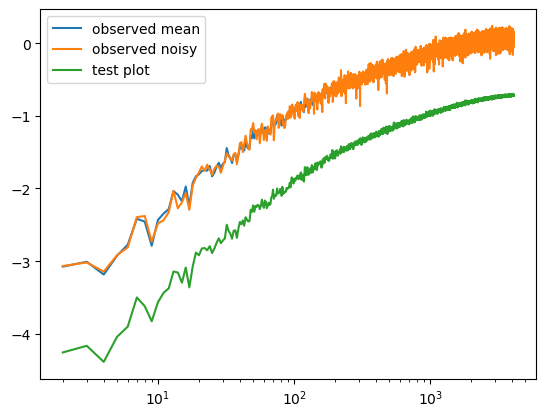

In [57]:
#plt.plot(ell_np, x_observed_np, label="observed mean")
plt.plot(ell_np, np.log10(D_l_fid*1e12), label="observed mean")
plt.plot(ell_np, np.log10(prepared["x_observed_noisy"]*1e12), label="observed noisy")
plt.plot(ell_np, prepared["x"][37]+12, label=  "test plot")
plt.xscale("log")
# plt.yscale("log")
plt.legend()

In [58]:
prepared["theta"][37]

tensor([24.1296,  0.1973,  3.7867,  0.1565,  0.0815,  0.0430, -0.6683,  0.4783,
         0.1141])

In [33]:
true_params

[18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758, 0.731, 0.415]

## Run SBI On The 512 Dataset

`USE_GAUSSIAN_BEAM_512` selects whether the no-beam or Gaussian-beam data vector is used for both training and observation.


In [ ]:
seed = 42
torch.manual_seed(seed)

# choose sbi method and train
inference = NPE(prior=prepared["prior"])
density_estimator_512 = inference.append_simulations(
    prepared["theta"],
    prepared["x"],
).train()

# do inference given observed data
x_o = np.log10(prepared["x_observed_noisy"])
posterior = inference.build_posterior(density_estimator_512)
samples = posterior.sample((40000,), x=x_o)

 Neural network successfully converged after 131 epochs.

  0%|          | 0/40000 [00:00<?, ?it/s]

In [42]:
posterior_save_path = r"outputs\posteriors\posterior_4096_sample_noisy.npy"
np.save(posterior_save_path, samples)

In [18]:
prepared["param_names"]

['P0',
 'xc',
 'beta',
 'alpha_m_P0',
 'alpha_m_xc',
 'alpha_m_beta',
 'alpha_z_P0',
 'alpha_z_xc',
 'alpha_z_beta']

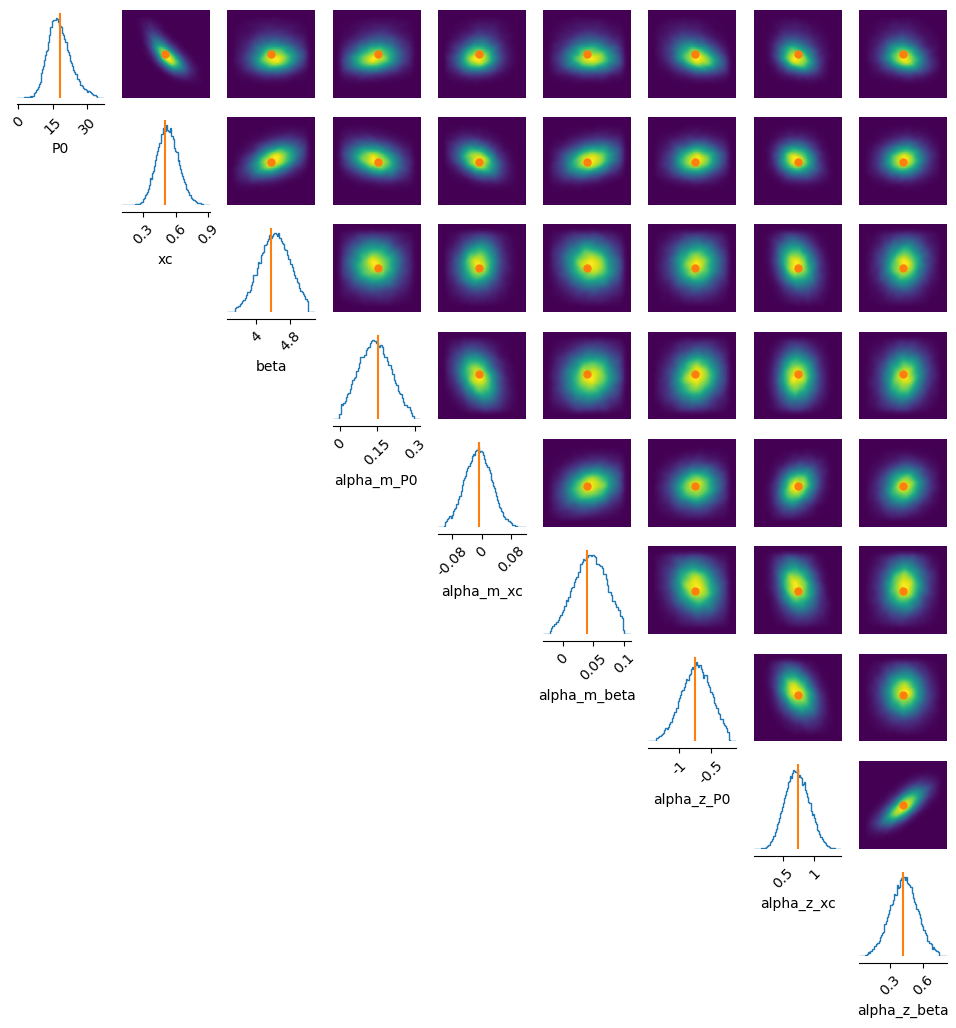

In [44]:
from matplotlib.ticker import MaxNLocator
theta_true = torch.as_tensor(np.array([true_params])).detach().cpu()


fig, axes = pairplot(
    samples,
    labels=prepared["param_names"],
    points=theta_true,
    figsize = (12, 12),
    upper="kde",
)

axes = np.asarray(axes)
n_params = axes.shape[0]

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        # Rotate all x tick labels
        ax.tick_params(axis="x", labelrotation=45)


        # Use fewer ticks everywhere
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

# Specifically enforce 3 x-ticks on diagonal histograms
for i in range(n_params):
    ax = axes[i, i]
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.tick_params(axis="x", labelrotation=45)

plt.savefig("pairplot_N4096_noisy_fixed_diff_seed.png", dpi=300)
plt.show()

In [20]:
theta_np = samples.detach().cpu().numpy()
print (theta_true)
summary = pd.DataFrame({
    "parameter": prepared["param_names"],
    "mean": np.mean(theta_np, axis=0),
    "median": np.median(theta_np, axis=0),
    "std": np.std(theta_np, axis=0),
    "q16": np.percentile(theta_np, 16, axis=0),
    "q84": np.percentile(theta_np, 84, axis=0),
    "q2.5": np.percentile(theta_np, 2.5, axis=0),
    "q97.5": np.percentile(theta_np, 97.5, axis=0),
})

print(summary)

tensor([[ 1.8100e+01,  4.9700e-01,  4.3500e+00,  1.5400e-01, -8.6500e-03,
          3.9300e-02, -7.5800e-01,  7.3100e-01,  4.1500e-01]],
       dtype=torch.float64)
      parameter       mean     median       std        q16        q84  \
0            P0  21.136080  21.002630  5.361562  15.718550  26.717012   
1            xc   0.492880   0.487063  0.101371   0.391278   0.595882   
2          beta   4.373413   4.376676  0.370629   3.982747   4.764219   
3    alpha_m_P0   0.136887   0.136052  0.061114   0.072832   0.200943   
4    alpha_m_xc  -0.012624  -0.013668  0.038914  -0.053045   0.027163   
5  alpha_m_beta   0.045616   0.046455  0.026519   0.017588   0.073894   
6    alpha_z_P0  -0.729476  -0.721000  0.239584  -0.977683  -0.477332   
7    alpha_z_xc   0.704475   0.700270  0.190260   0.513334   0.896995   
8  alpha_z_beta   0.447008   0.448007  0.129590   0.309669   0.584196   

        q2.5      q97.5  
0  11.050444  31.769513  
1   0.311417   0.706057  
2   3.652018   5.076412  


## Dependence on dataset


In [21]:
import torch
import pandas as pd

def posterior_summary(samples, param_names=None):
    """
    samples: torch.Tensor or np.ndarray with shape (N_samples, N_params)
    """

    if not torch.is_tensor(samples):
        samples = torch.as_tensor(samples)

    samples = samples.detach().cpu()

    n_params = samples.shape[1]

    if param_names is None:
        param_names = [f"theta_{i}" for i in range(n_params)]

    mean = samples.mean(dim=0)
    median = samples.median(dim=0).values
    var = samples.var(dim=0, unbiased=True)
    std = samples.std(dim=0, unbiased=True)

    # Equal-tailed credible intervals
    ci68 = torch.quantile(samples, torch.tensor([0.16, 0.84]), dim=0)
    ci95 = torch.quantile(samples, torch.tensor([0.025, 0.975]), dim=0)

    summary = pd.DataFrame({
        "mean": mean.numpy(),
        "median": median.numpy(),
        "variance": var.numpy(),
        "std": std.numpy(),
        "68% lower": ci68[0].numpy(),
        "68% upper": ci68[1].numpy(),
        "95% lower": ci95[0].numpy(),
        "95% upper": ci95[1].numpy(),
    }, index=param_names)

    return summary


In [31]:
dataset_number = [4096, 2048, 1024, 512, 256, 128, 64]
# choose sbi method and train

x_o = np.log10(prepared["x_observed_noisy"])

dict_for_number = {}

for number_data in dataset_number:
    inference = NPE(prior=prepared["prior"])
    density_estimator_temp = inference.append_simulations(
        prepared["theta"][:number_data],
        prepared["x"][:number_data],
    ).train()

    # do inference given observed data
    posterior = inference.build_posterior(density_estimator_temp)
    samples = posterior.sample((10000,), x=x_o)

    posterior_summary_df = posterior_summary(samples, param_names=prepared["param_names"])
    dict_for_number[number_data] = [posterior_summary_df, samples]
    

 Neural network successfully converged after 195 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 130 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 153 epochs.

...

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 195 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 179 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

In [32]:
std_dataset = []
for numb in dataset_number:
    std_dataset.append(dict_for_number[numb][0]["std"]) 
std_dataset = np.array(std_dataset)

In [33]:
mean_dataset = []
for numb in dataset_number:
    mean_dataset.append(dict_for_number[numb][0]["mean"])
mean_dataset = np.array(mean_dataset)

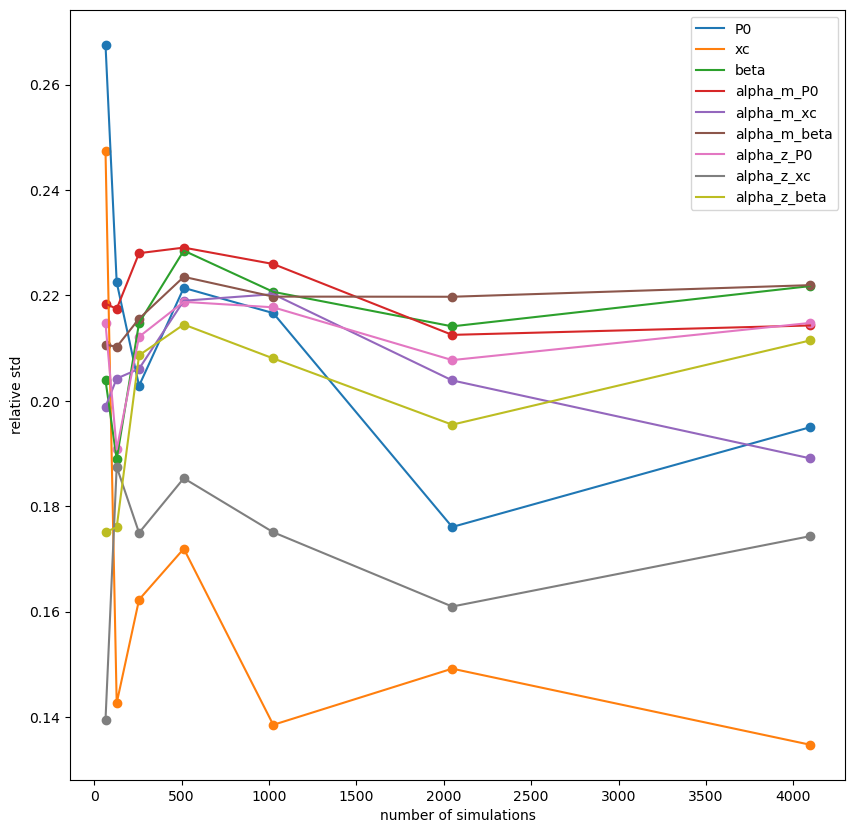

In [38]:
plt.figure(figsize=(10, 10))

for i, param_name in enumerate(prepared["param_names"]):
    Delta_param = SOBOL_PRIOR_BOUNDS[param_name][1] - SOBOL_PRIOR_BOUNDS[param_name][0]
    plt.plot(dataset_number, abs(std_dataset[:,i]/Delta_param), label = param_name)
    plt.scatter(dataset_number, abs(std_dataset[:,i]/Delta_param))
# plt.yscale("log")
plt.legend()
plt.xlabel("number of simulations")
plt.ylabel("relative std")
plt.savefig("../plots/SBI_plots/relative_std_vs_number_simulations_max4096_fixed_noisy.png", dpi=300)
plt.show()

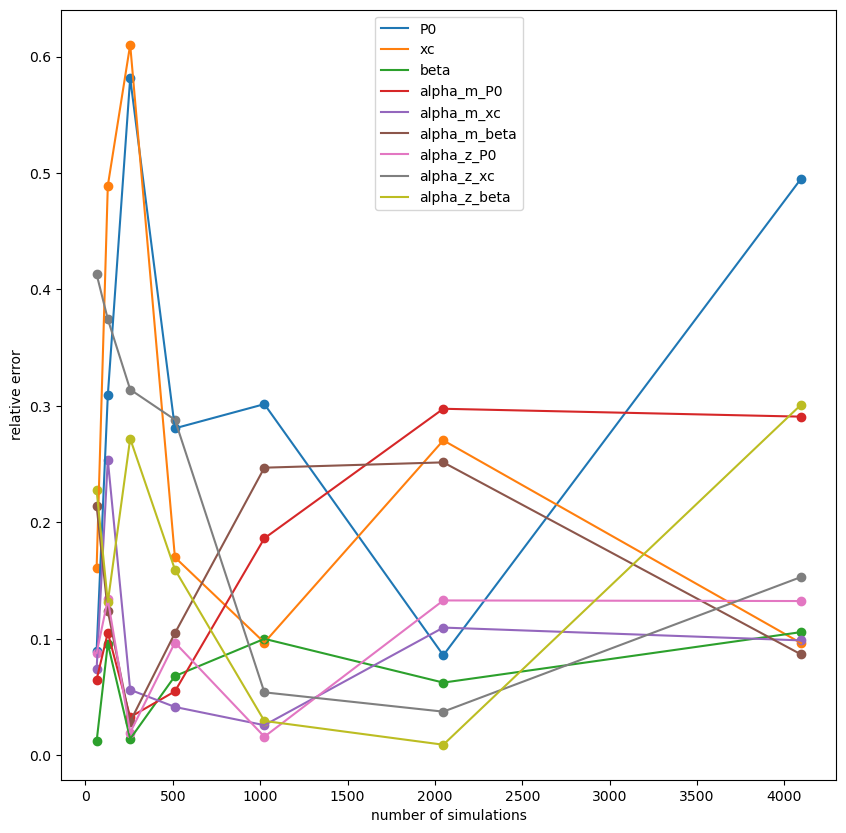

In [37]:
plt.figure(figsize=(10, 10))

for i, param_name in enumerate(prepared["param_names"]):
    plt.plot(dataset_number, abs((mean_dataset[:,i] - np.array(theta_true)[0][i])/std_dataset[:,i]), label = param_name)
    plt.scatter(dataset_number, abs((mean_dataset[:,i] - np.array(theta_true)[0][i])/std_dataset[:,i]))
# plt.yscale("log")
plt.legend()
plt.xlabel("number of simulations")
plt.ylabel("relative error")
plt.savefig("../plots/SBI_plots/relative_error_vs_number_simulations_max4096_fixed_noisy.png", dpi=300)
plt.show()

In [28]:
theta_true

tensor([[ 1.8100e+01,  4.9700e-01,  4.3500e+00,  1.5400e-01, -8.6500e-03,
          3.9300e-02, -7.5800e-01,  7.3100e-01,  4.1500e-01]],
       dtype=torch.float64)

# Generating the "observed" function

In [55]:
theta_true

tensor([[ 1.8100e+01,  4.9700e-01,  4.3500e+00,  1.5400e-01, -8.6500e-03,
          3.9300e-02, -7.5800e-01,  7.3100e-01,  4.1500e-01]],
       dtype=torch.float64)

In [66]:
theta_np[1009]

array([ 3.0930782e+01,  3.7025276e-01,  4.5386996e+00,  2.9002517e-01,
       -3.5683136e-02,  1.0109487e-02, -5.0351870e-01,  4.3198529e-01,
        2.4153362e-01], dtype=float32)